# AG-HYPOPT · Trial 33

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Thirty-two trials are registered; cell 2 reports `phase = trials` (32/5), so proposals carry expected-improvement (ei) values. **Best = trial_21** (objective 0.1074), with **trial_30** (0.1083) second. Key facts (mu travel = `lr_mu*(1 - mu_anneal/2)`):

- best (all 0 div): trial_21 0.1074 (0.138), trial_30 0.1083 (0.134), trial_22 0.1095 (0.137), trial_32 0.1097 (0.137), trial_08 0.1099 (0.134), trial_15 0.1103 (0.127), trial_31 0.1106 (0.131), trial_24 0.1108 (0.133), trial_16 0.1112 (0.128), trial_12 0.1115 (0.128), trial_18 0.1121 (0.138), trial_09 = trial_20 = trial_25 0.1126, trial_01 = trial_14 = trial_23 0.1127.
- worse: trial_13 0.1132, trial_05 = trial_19 0.1135, trial_07 0.1140, trial_27 0.1149 (0.194), trial_06 = trial_11 0.1188.
- diverging at 1nW T05 (near-optimum travel): trial_29 0.1331, trial_26 0.1368, trial_28 0.1370. Other diverging: trial_17 0.1329, trial_10 0.1975, trial_03 0.1362, trial_04 0.1418, trial_02 0.1449.

State of play: single optimum spike at travel ~0.137-0.138 with balanced gamma knobs; **seven surviving samples below 0.111** (0.1074-0.1106) whenever the 1nW T05 cell survives, otherwise the diverged cell costs ~0.02-0.07. The schedule family is converged; the sporadic low-count divergence is the only remaining lever (and it is structural). Objective = T-weighted (w=0.25+0.75*T/100) mean of capped rel-sq errors over the 8-experiment benchmark.

In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_33'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 40    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (32/5 trials)
ID |     ei | params
 1 | 3.7607 | {"gamma_anneal": 0.47787140045816867, "lr_gamma": 0.413811540790883, "lr_mu": 0.173286617071756, "mu_anneal": 0.34981794761951657}
 2 | 2.7218 | {"gamma_anneal": 0.4772185367463655, "lr_gamma": 0.4422110000098617, "lr_mu": 0.1557463879638767, "mu_anneal": 0.7726223186926501}
 3 | 3.5565 | {"gamma_anneal": 0.5093570687624843, "lr_gamma": 0.4526183229696302, "lr_mu": 0.1700090220164033, "mu_anneal": 0.3453864544362014}
 4 | 2.1519 | {"gamma_anneal": 0.5173280091419662, "lr_gamma": 0.47180460197060176, "lr_mu": 0.15146771788379434, "mu_anneal": 0.35739624147042576}
 5 | 2.9330 | {"gamma_anneal": 0.4964463378133721, "lr_gamma": 0.48925125124325997, "lr_mu": 0.15487176513890855, "mu_anneal": 0.3480084786914143}
 6 | 2.9757 | {"gamma_anneal": 0.5383092831179237, "lr_gamma": 0.48119769227532033, "lr_mu": 0.10525414441514701, "mu_anneal": 0.35095442701700086}
 7 | 3.6790 | {"gamma_anneal": 0.06864472599853576, "lr_gamma": 0.45161

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

Cell 2 is in the informed `trials` phase (32 trials). Candidate travel `lr_mu*(1 - mu_anneal/2)`, with ei:
- candidate 1: **ei 3.76** — `lr_mu=0.1733`, `mu_anneal=0.3498` (travel **0.143**), `lr_gamma=0.4138`, `gamma_anneal=0.4779`.
- candidate 7: ei 3.68 — `lr_mu=0.1558`, `mu_anneal=0.3469` (travel 0.129), `lr_gamma=0.4516`, `gamma_anneal=0.0686` (very low).
- candidate 3: ei 3.56 — `lr_mu=0.1700`, `mu_anneal=0.3454` (travel 0.141), `lr_gamma=0.4526`, `gamma_anneal=0.5094`.
- candidate 6: ei 2.98 — `lr_mu=0.1053`, `mu_anneal=0.3510` (travel 0.087, low), `lr_gamma=0.4812`.
- candidate 5: ei 2.93 — `lr_mu=0.1549`, `mu_anneal=0.3480` (travel 0.128), `lr_gamma=0.4893`.

Candidate 1 has the highest ei and sits just above the optimum (travel 0.143, between trial_14's 0.140 and trial_11's 0.159) with balanced gamma knobs (`lr_gamma=0.4138`, `gamma_anneal=0.4779`) in the proven-safe range. Candidate 3 is at travel 0.141 with similar knobs and close ei. Given the optimum band (0.127-0.138) is very well sampled, sampling just past it (0.143) with the maximum-ei candidate is a sensible small probe of whether the spike extends upward, while keeping the balanced gamma that has been reliable. Candidate 7 carries a nearly-zero `gamma_anneal=0.069` (untested).

I choose candidate 1 (1 goes into the SET cell below).

In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 1            # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'gamma_anneal': 0.47787140045816867, 'lr_gamma': 0.413811540790883, 'lr_mu': 0.173286617071756, 'mu_anneal': 0.34981794761951657}
Running  1nW Trans05 ... 

μ 9.39 -> 9.74 | γ 8.5 -> 4.27 | NLL 1.27


Running  1nW Trans20 ... 

μ 17.32 -> 44.85 | γ 8.5 -> 6.16 | NLL 5.19


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 77.30 | γ 14.1 -> 14.43 | NLL 3.40


Running 3nW Trans100 ... 

μ 175.71 -> 113.56 | γ 14.1 -> 13.99 | NLL 3.22



Total: 7.9 min


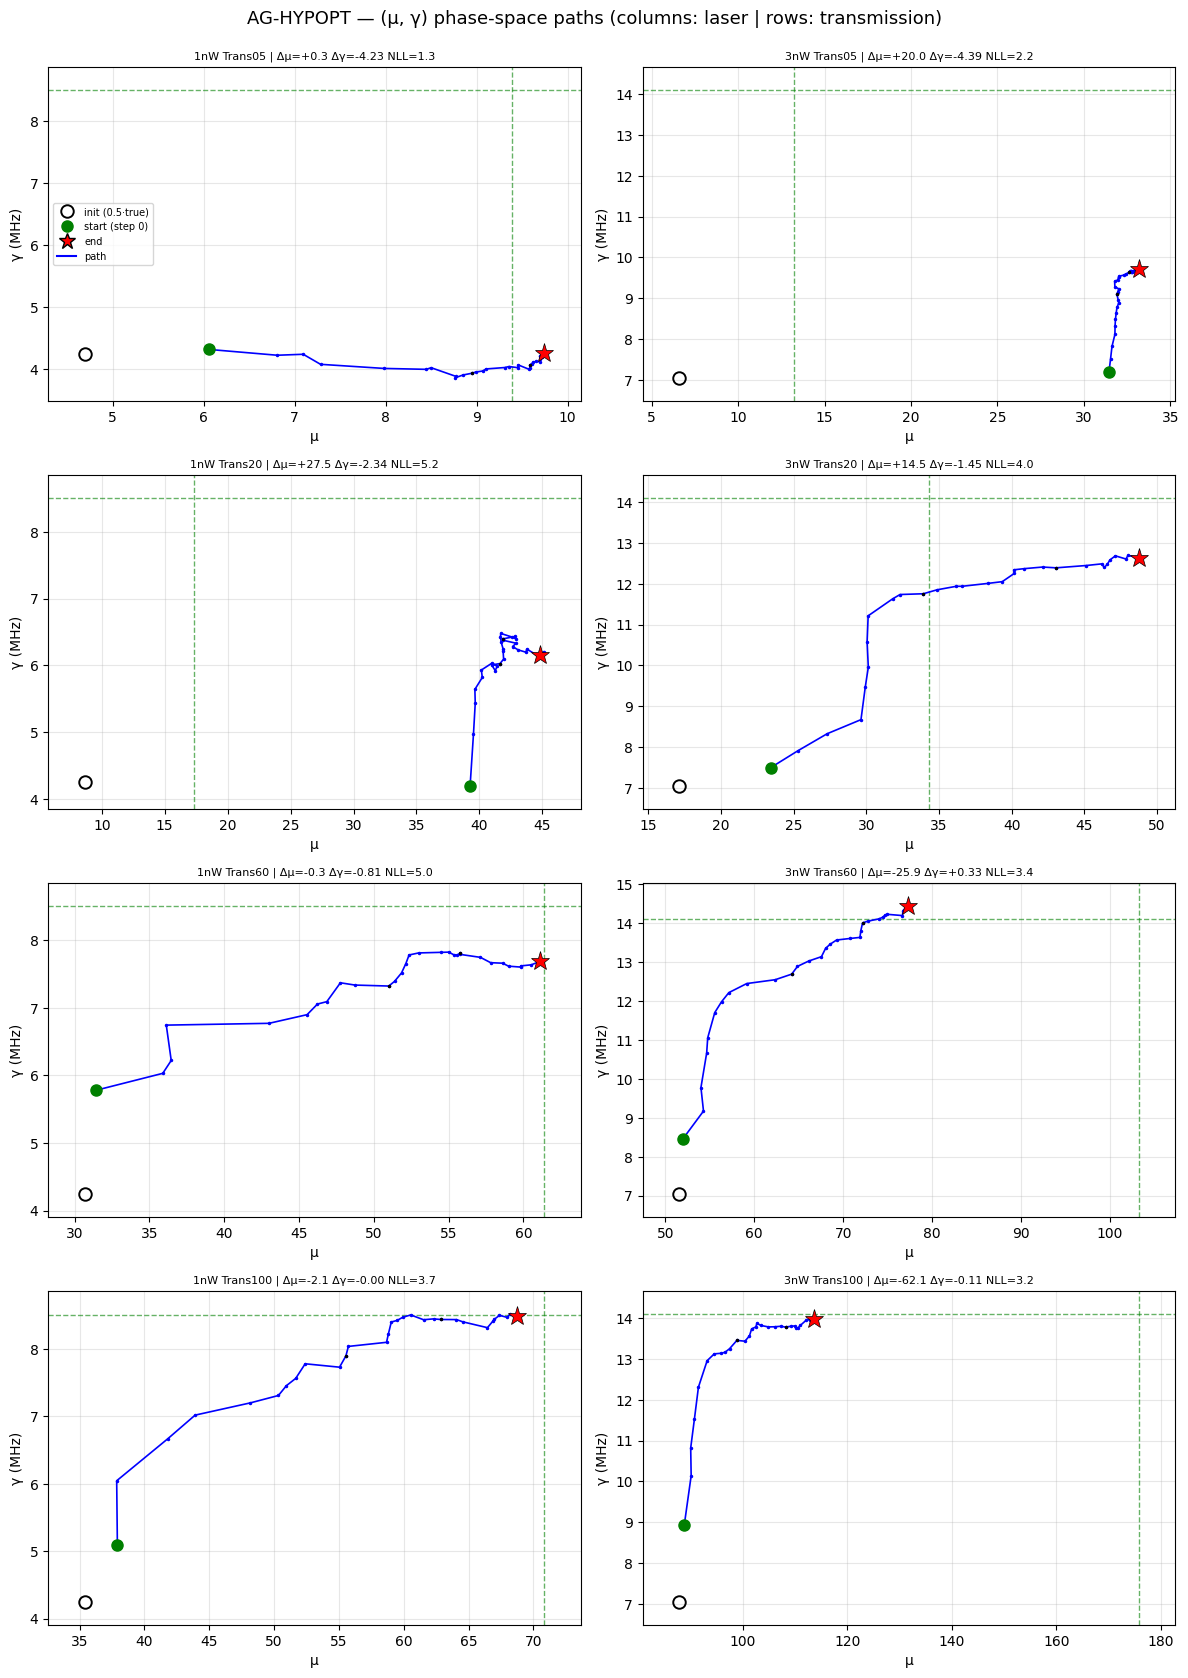

trial finished in 8.0 min
objective = 0.1120 ± 0.0825
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39    9.74    +3.7 |     8.50    4.27   -49.7
1nW Trans20       17.32   44.85  +159.0 |     8.50    6.16   -27.5
1nW Trans60       61.37   61.12    -0.4 |     8.50    7.69    -9.6
1nW Trans100       70.82   68.73    -3.0 |     8.50    8.50    -0.1
3nW Trans05       13.20   33.17  +151.2 |    14.10    9.71   -31.1
3nW Trans20       34.28   48.73   +42.2 |    14.10   12.65   -10.3
3nW Trans60      103.20   77.30   -25.1 |    14.10   14.43    +2.3
3nW Trans100      175.71  113.56   -35.4 |    14.10   13.99    -0.8

weighted objective (T-graded, cap=1.0) = 0.1120 | diverged cells: 0
μ: RMSE 27.164 (rel 80.5%, bias -3.512) | γ: RMSE 2.384 (rel 23.5%, bias -1.626)


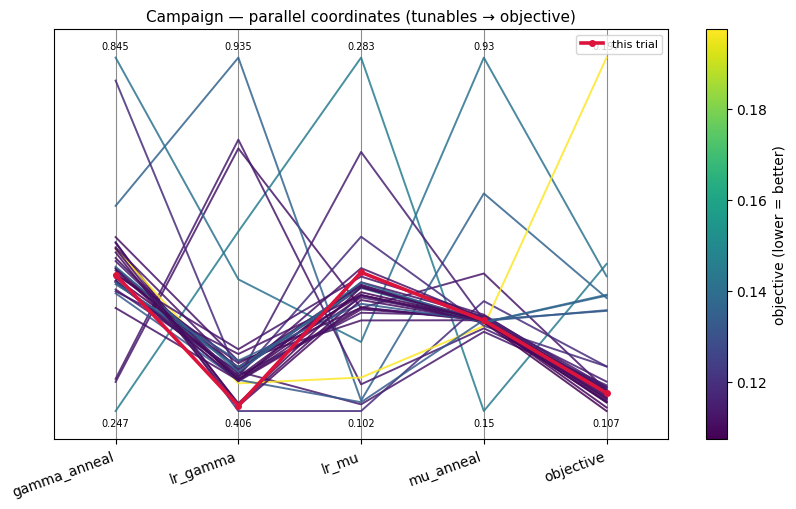

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Trial 33 ran the highest-EI candidate (candidate 1, ei=3.76): `lr_mu=0.1733`, `mu_anneal=0.3498` (effective mu travel 0.143), `lr_gamma=0.4138`, `gamma_anneal=0.4779`. It completed in 8.0 min with objective **0.1120 +/- 0.0825** and **0 diverged cells** — mid-band. Ranking: trial_21 0.1074 < trial_30 0.1083 < trial_22 0.1095 < trial_32 0.1097 < trial_08 0.1099 < trial_15 0.1103 < trial_31 0.1106 < trial_24 0.1108 < trial_16 0.1112 < trial_12 0.1115 < **trial_33 0.1120** < trial_18 0.1121 < ...

Aggregate accuracy: **mu rel-RMSE 80.5%** (RMSE 27.16, bias -3.51); **gamma rel-RMSE 23.5%** (RMSE 2.38, bias -1.63).

Per-cell relative errors:
- **mu:** 1nW T05 +3.7%, T20 +159.0%, T60 -0.4%, T100 -3.0% | 3nW T05 +151.2%, T20 +42.2%, T60 -25.1%, T100 -35.4%.
- **gamma:** 1nW T05 -49.7%, T20 -27.5%, T60 -9.6%, T100 -0.1% | 3nW T05 -31.1%, T20 -10.3%, T60 +2.3%, T100 -0.8%.

This sampled just past the optimum (travel 0.143, between trial_14's 0.140 and trial_11's 0.159) and came out at 0.1120 — divergence-free but clearly mid-band, worse than every sub-0.111 survival. So the spike does **not** extend upward: the objective rises as travel moves from 0.137 to 0.143, mirroring its rise on the low side. The optimum is confirmed to be a narrow peak at travel ~0.137-0.138 with balanced gamma, and trial_21 (0.1074) remains the best.

**Summary:** Trial 33 (lr_mu=0.1733, mu_anneal=0.3498, lr_gamma=0.4138, gamma_anneal=0.4779): objective 0.1120 +/- 0.0825 with 0 diverged cells; sampling just above the optimum (travel 0.143) landed mid-band, so the spike does not extend upward and trial_21 (0.1074) stays best.
**Key insight:** Travel 0.143 gives 0.1120, slightly worse than the 0.137-0.138 optimum, confirming the spike peaks at ~0.137-0.138 and falls off both ways.

Structural-change proposals (score, likelihood, model, protocol) belong here as notes for
Anuar: describe them, never act on them, never stop the campaign because of them.
**Notes for Anuar (not acted on).** Consistent with prior findings: the mu axis is a single narrow optimum; the schedule is converged at ~0.108; the divergence is the only remaining factor. Recorded only, not acted on.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = "Trial 33 (lr_mu=0.1733, mu_anneal=0.3498, lr_gamma=0.4138, gamma_anneal=0.4779): objective 0.1120 +/- 0.0825 with 0 diverged cells; sampling just above the optimum (travel 0.143) landed mid-band, so the spike does not extend upward and trial_21 (0.1074) stays best"      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = "Travel 0.143 gives 0.1120, slightly worse than the 0.137-0.138 optimum, confirming the spike peaks at ~0.137-0.138 and falls off both ways"  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_33 | current best: trial_21


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_34.ipynb. Open it and follow its cells from the top.
